# 03 - Pose Estimation

Ejemplos para modelos de pose. Los keypoints quedan como listas `[[x, y, score], ...]` dentro del `DataFrame` y se pueden plotear directamente sobre la imagen.


In [ ]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "vision").exists():
    PROJECT_ROOT = cwd
elif len(cwd.parents) >= 3 and (cwd.parents[2] / "vision").exists():
    PROJECT_ROOT = cwd.parents[2]
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_DIR = PROJECT_ROOT / "vision" / "yolo" / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE = (
    str(NOTEBOOK_DIR / "bus.jpg")
    if (NOTEBOOK_DIR / "bus.jpg").exists()
    else "https://ultralytics.com/images/bus.jpg"
)

import pandas as pd
from vision.yolo.infer import predict_image
from vision.yolo.plotting import plot_pose_keypoints, plot_image_detections

MODEL = (
    str(NOTEBOOK_DIR / "yolo11n-pose.pt")
    if (NOTEBOOK_DIR / "yolo11n-pose.pt").exists()
    else "yolo11n-pose.pt"
)


In [ ]:
df = predict_image(MODEL, IMAGE, confidence=0.25, task="pose")
print(
    df[
        [
            "frame",
            "class_name",
            "confidence",
            "xmin",
            "ymin",
            "xmax",
            "ymax",
            "keypoints",
        ]
    ].head()
)


/home/juan/miniforge3/envs/ultralytics/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


   frame class_name  confidence        xmin        ymin        xmax  \
0      0     person    0.887020   47.995548  399.896820  243.547379   
1      0     person    0.880957  669.009521  387.746185  810.000000   
2      0     person    0.877843  222.960892  405.042847  343.938080   
3      0     person    0.457451    0.001699  431.898560   67.954063   

         ymax                                          keypoints  
0  905.872437  [[142.35540771484375, 441.8186950683594, 0.990...  
1  878.145264  [[797.1577758789062, 434.9602966308594, 0.1583...  
2  859.047791  [[292.5862121582031, 450.84527587890625, 0.989...  
3  907.378235  [[9.355803489685059, 505.0254211425781, 0.0985...  


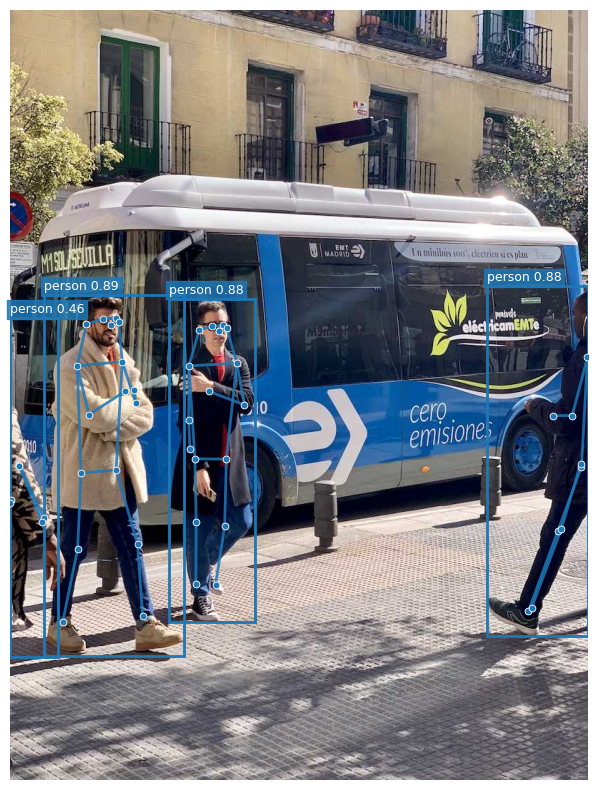

In [ ]:
# Plot directo de skeleton + cajas
plot_pose_keypoints(
    IMAGE,
    df,
    keypoint_threshold=0.25,
    save_to=OUTPUT_DIR / "03_pose_keypoints.png",
)


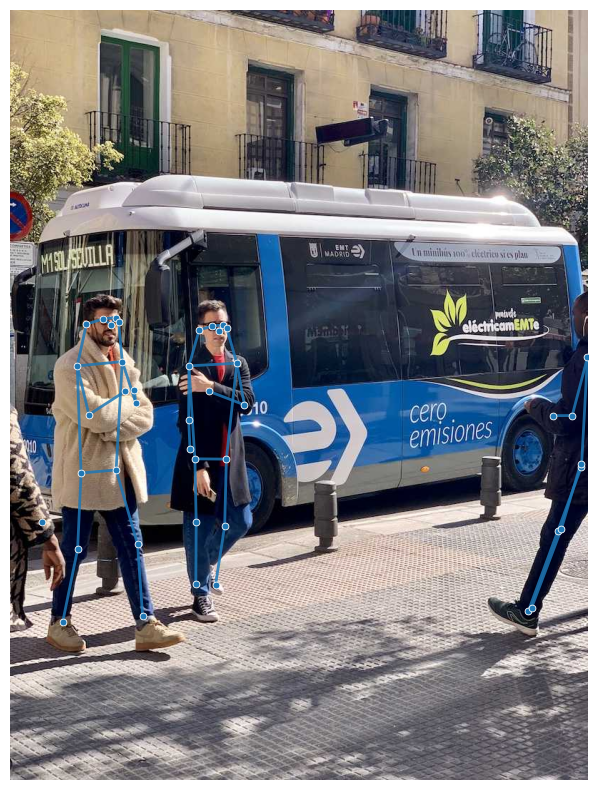

In [ ]:
# Solo keypoints, sin cajas ni labels
plot_pose_keypoints(
    IMAGE,
    df,
    draw_boxes=False,
    draw_labels=False,
    keypoint_threshold=0.35,
    save_to=OUTPUT_DIR / "03_keypoints_only.png",
)


In [ ]:
# Convertir keypoints a formato largo para analisis tabular
rows = []
for det_idx, row in df.iterrows():
    keypoints = row.get("keypoints")
    if not isinstance(keypoints, list):
        continue
    for kp_idx, kp in enumerate(keypoints):
        if len(kp) >= 3:
            x, y, score = kp[:3]
        else:
            x, y = kp[:2]
            score = 1.0
        rows.append(
            {
                "detection": det_idx,
                "class_name": row["class_name"],
                "keypoint": kp_idx,
                "x": x,
                "y": y,
                "score": score,
            }
        )
keypoints_long = pd.DataFrame(rows)
print(keypoints_long.head())


   detection class_name  keypoint           x           y     score
0          0     person         0  142.355408  441.818695  0.990963
1          0     person         1  147.976501  431.377625  0.928967
2          0     person         2  130.535889  433.332367  0.986937
3          0     person         3  152.280060  437.490875  0.427071
4          0     person         4  107.183853  440.629395  0.931489


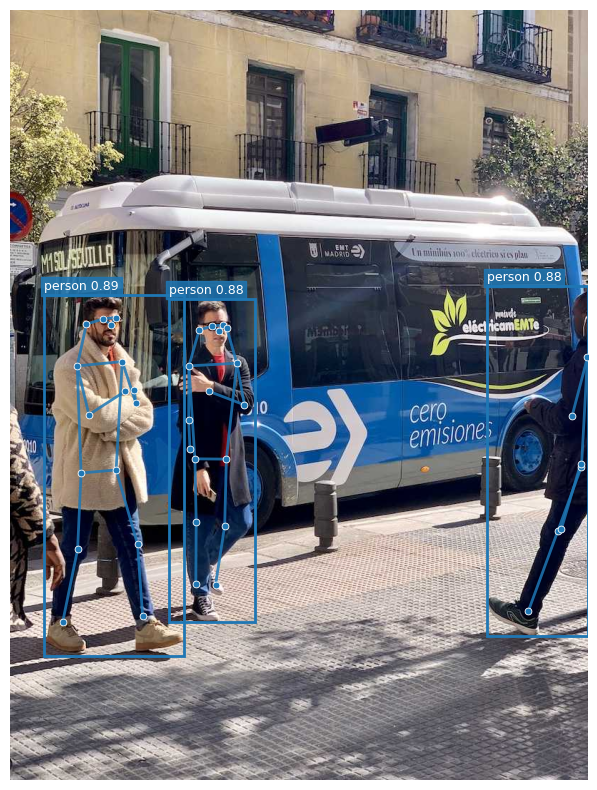

In [ ]:
# Ejemplo: quedarte con keypoints confiables y replotear solo detecciones de alta confianza
high_conf = df[df["confidence"].ge(0.5)]
plot_image_detections(
    IMAGE,
    high_conf,
    draw_boxes=True,
    draw_polygons=False,
    draw_keypoints=True,
    keypoint_threshold=0.5,
    save_to=OUTPUT_DIR / "03_high_conf_pose.png",
)
